### Importing Libraries

In [22]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import numpy as np
import community as community_louvain
import itertools
import random
import matplotlib.cm as cm


from collections import Counter
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community import label_propagation_communities
from collections import Counter

#Suppress warnings
import warnings
warnings.filterwarnings('ignore')

### loading the edge list

In [3]:
# Path to the file
edge_file = 'facebook_combined-1.txt'

# Read as an undirected graph
G = nx.read_edgelist(edge_file, nodetype=int, comments='#', data=False)
print("Loaded graph.")

Loaded graph.


### Basic Network Characteristric

In [25]:
# Basic properties
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
degrees = [d for n,d in G.degree()]
avg_degree = sum(degrees) / n_nodes

print("*** Basic Network Characteristics ***")
print(f"Nodes: {n_nodes}")
print(f"Edges: {n_edges}")
print(f"Density: {density:.6f}")
print(f"Average degree: {avg_degree:.3f}")

*** Basic Network Characteristics ***
Nodes: 4039
Edges: 88234
Density: 0.010820
Average degree: 43.691


#### Quick visualisation (small, so layout works). 

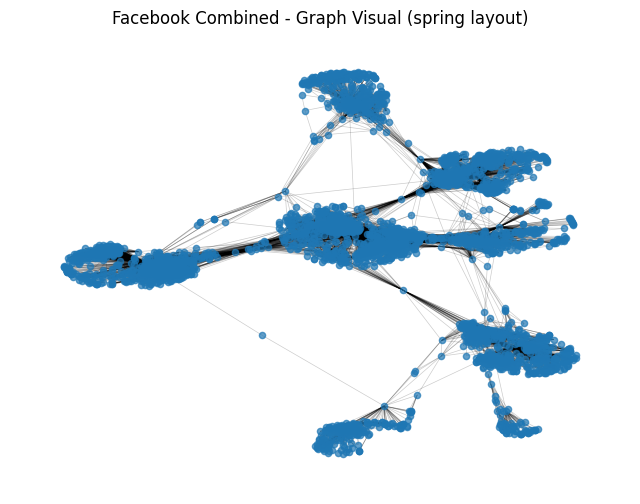

In [24]:
#For large networks this will be dense.
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)   # deterministic layout
nx.draw_networkx_nodes(G, pos, node_size=20, node_color='tab:blue', alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)
plt.title('Facebook Combined - Graph Visual (spring layout)')
plt.axis('off')
plt.show()

### Edge betweeness centrality

In [26]:
t0 = time.time()
edge_bet = nx.edge_betweenness_centrality(G)   # dictionary: (u,v) -> value
t1 = time.time()
print(f"Computed edge betweenness in {t1-t0:.1f}s. Number of edges scored: {len(edge_bet)}")

# Converting to list and stats
values = np.array(list(edge_bet.values()))
print("Edge betweenness stats:")
print(f"min={values.min():.6f}, mean={values.mean():.6f}, max={values.max():.6f}")


Computed edge betweenness in 151.7s. Number of edges scored: 88234
Edge betweenness stats:
min=0.000000, mean=0.000042, max=0.171493


#### Plot Distribution

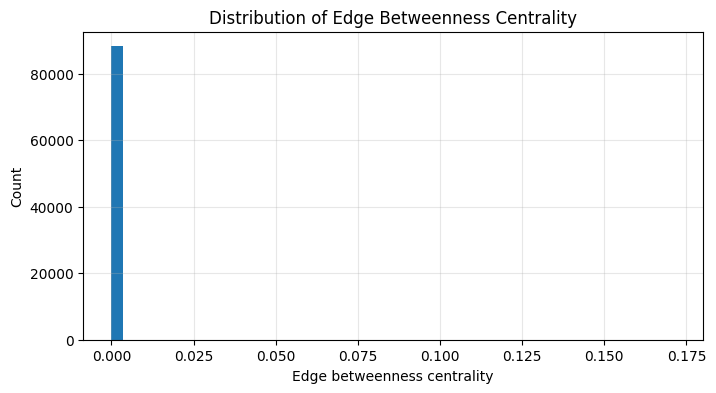

In [27]:
# Plot distribution (histogram)
plt.figure(figsize=(8,4))
plt.hist(values, bins=50, density=False)
plt.xlabel('Edge betweenness centrality')
plt.ylabel('Count')
plt.title('Distribution of Edge Betweenness Centrality')
plt.grid(alpha=0.3)
plt.show()


### Community Detection

In [28]:

# Louvain partition
partition = community_louvain.best_partition(G)
# Convert to cluster which is members
clusters = {}
for node, com in partition.items():
    clusters.setdefault(com, []).append(node)

# Summary
cluster_sizes = sorted([len(m) for m in clusters.values()], reverse=True)
print("Louvain detected communities:", len(cluster_sizes))
print("Top 10 community sizes (Louvain):", cluster_sizes[:10])


Louvain detected communities: 16
Top 10 community sizes (Louvain): [548, 535, 446, 430, 423, 350, 326, 237, 226, 206]


#### Visualization

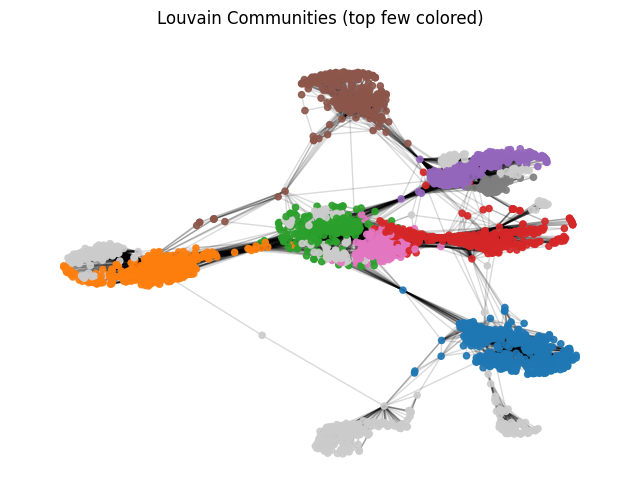

In [30]:
# color nodes by community (only plot top k communities distinctly)
# number of biggest communities to color distinctly i.e rest grey
kplot = 8   
largest_coms = [c for c,s in sorted(clusters.items(), key=lambda x: len(x[1]), reverse=True)[:kplot]]
color_map = {}
cmap = cm.get_cmap('tab10')
for i,c in enumerate(largest_coms):
    for node in clusters[c]:
        color_map[node] = cmap(i)

# default color for others
node_colors = [color_map.get(n, (0.8,0.8,0.8)) for n in G.nodes()]

plt.figure(figsize=(8,6))
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.15)
plt.title('Louvain Communities (top few colored)')
plt.axis('off')
plt.show()

In [20]:
partition_louvain = community_louvain.best_partition(G)
# Count nodes per community
louvain_counts = Counter(partition_louvain.values())
print("Louvain Communities:")
for comm_id, size in louvain_counts.most_common(10):
    print(f"Community {comm_id}: {size} nodes")

Louvain Communities:
Community 8: 548 nodes
Community 4: 535 nodes
Community 7: 435 nodes
Community 1: 430 nodes
Community 3: 423 nodes
Community 0: 350 nodes
Community 5: 325 nodes
Community 10: 237 nodes
Community 14: 226 nodes
Community 13: 206 nodes


In [16]:
#Creating a subgraph for visualization (500 random nodes)
sample_nodes = random.sample(G.nodes(), 500)
H = G.subgraph(sample_nodes)

#### Visualization

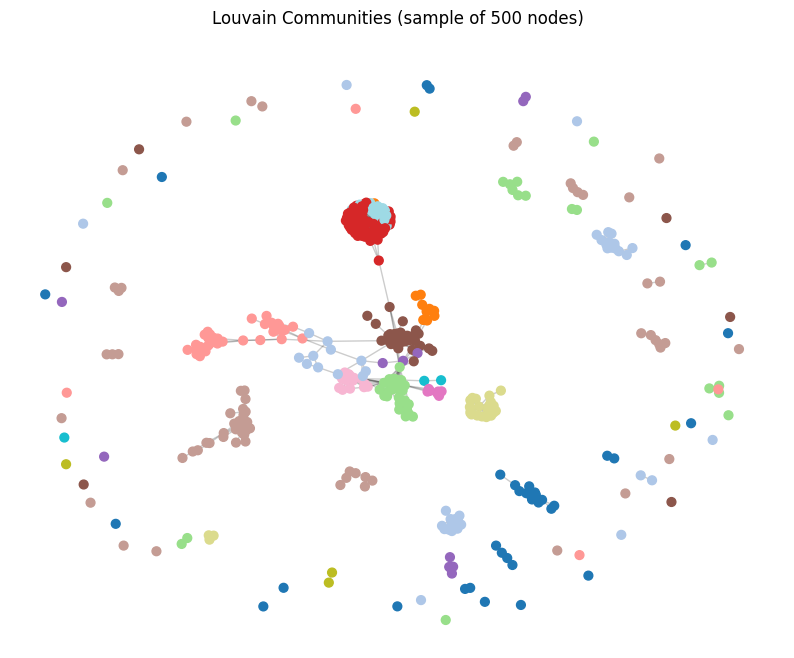

In [17]:
partition_louvain = community_louvain.best_partition(G)
colors_louvain = [partition_louvain[n] for n in H.nodes()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, seed=42)
nx.draw_networkx_nodes(H, pos, node_color=colors_louvain, cmap=plt.cm.tab20, node_size=40)
nx.draw_networkx_edges(H, pos, alpha=0.2)
plt.title("Louvain Communities (sample of 500 nodes)")
plt.axis("off")
plt.show()


### Label Propagation Community Detection 

In [11]:
lp_communities = list(label_propagation_communities(G))
lp_sizes = sorted([len(c) for c in lp_communities], reverse=True)
print("\nLabel Propagation Communities:")
for i, size in enumerate(lp_sizes[:10]):
    print(f"Community {i}: {size} nodes")


Label Propagation Communities:
Community 0: 1030 nodes
Community 1: 753 nodes
Community 2: 547 nodes
Community 3: 469 nodes
Community 4: 226 nodes
Community 5: 215 nodes
Community 6: 198 nodes
Community 7: 179 nodes
Community 8: 60 nodes
Community 9: 49 nodes


#### Visualization

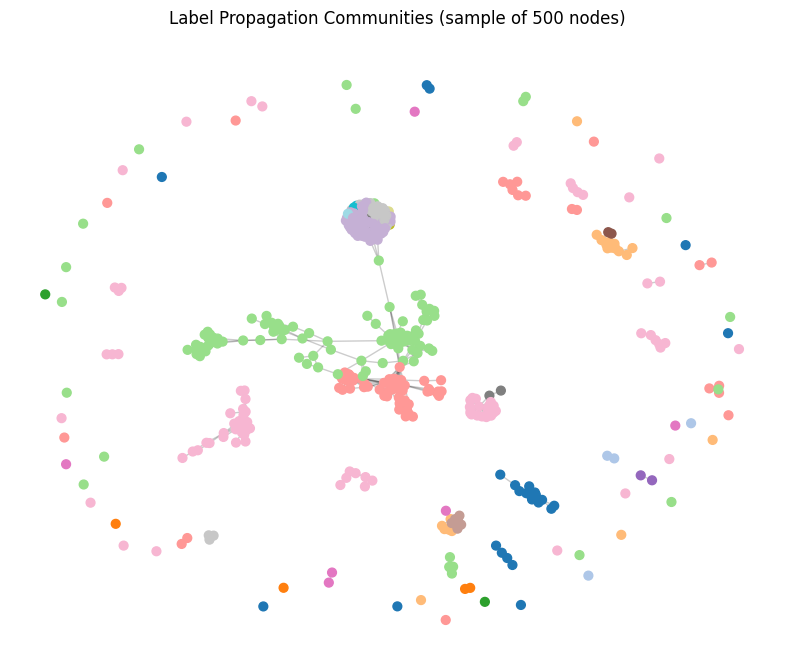

In [18]:
lp_communities = list(label_propagation_communities(G))
lp_map = {}
for i, comm in enumerate(lp_communities):
    for node in comm:
        lp_map[node] = i
colors_lp = [lp_map[n] for n in H.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(H, pos, node_color=colors_lp, cmap=plt.cm.tab20, node_size=40)
nx.draw_networkx_edges(H, pos, alpha=0.2)
plt.title("Label Propagation Communities (sample of 500 nodes)")
plt.axis("off")
plt.show()

#### Comparing number of communities detected

In [12]:

print(f"\nTotal communities - Louvain: {len(louvain_counts)}, Label Propagation: {len(lp_sizes)}")


Total communities - Louvain: 15, Label Propagation: 44


#### Modularity of Louvain partition


In [32]:
mod = community_louvain.modularity(partition, G)
print(f"Louvain modularity: {mod:.4f}")

#clustering coefficient by community (mean of node clustering)

clust_coeff = nx.clustering(G)  # dict node i.e clustering
for i, (com_id, members) in enumerate(sorted(clusters.items(), key=lambda x: len(x[1]), reverse=True)[:6]):
    vals = [clust_coeff[n] for n in members]
    print(f"Community {i} (size={len(members)}): mean clustering={np.mean(vals):.3f}")


Louvain modularity: 0.8349
Community 0 (size=548): mean clustering=0.623
Community 1 (size=535): mean clustering=0.510
Community 2 (size=446): mean clustering=0.562
Community 3 (size=430): mean clustering=0.585
Community 4 (size=423): mean clustering=0.598
Community 5 (size=350): mean clustering=0.657


#### Numerical Comparision

In [33]:
# Louvain
partition_louvain = community_louvain.best_partition(G)
communities_louvain = {}
for node, comm in partition_louvain.items():
    communities_louvain.setdefault(comm, []).append(node)

louvain_stats = {
    "Algorithm": "Louvain",
    "Num_Communities": len(communities_louvain),
    "Largest_Community": max(len(c) for c in communities_louvain.values()),
    "Smallest_Community": min(len(c) for c in communities_louvain.values()),
    "Average_Size": sum(len(c) for c in communities_louvain.values()) / len(communities_louvain)
}

# Label Propagation
lp_communities = list(label_propagation_communities(G))
lp_stats = {
    "Algorithm": "Label Propagation",
    "Num_Communities": len(lp_communities),
    "Largest_Community": max(len(c) for c in lp_communities),
    "Smallest_Community": min(len(c) for c in lp_communities),
    "Average_Size": sum(len(c) for c in lp_communities) / len(lp_communities)
}

In [34]:
# Comparison Table
df_comparison = pd.DataFrame([louvain_stats, lp_stats])
print(df_comparison)

           Algorithm  Num_Communities  Largest_Community  Smallest_Community  \
0            Louvain               16                548                  19   
1  Label Propagation               44               1030                   2   

   Average_Size  
0    252.437500  
1     91.795455  
